In [ ]:
# Load data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import Perceptron as SKPerceptron

FEATURES = ['variance', 'skewness', 'curtosis', 'entropy']
raw = pd.read_csv(
    "https://archive.ics.uci.edu/ml/machine-learning-databases/00267/data_banknote_authentication.txt",
    names=FEATURES + ['label']
)
raw['label'] = raw['label'].astype(int)

In [ ]:
print(f"Shape: {raw.shape[0]} rows x {raw.shape[1]} cols")
print(f"\nMissing values:\n{raw.isnull().sum()}")
print(f"\nClass balance:\n{raw['label'].value_counts(normalize=True).round(3)}")
raw.describe().T

Shape: 1372 rows x 5 cols

Missing values:
variance    0
skewness    0
curtosis    0
entropy     0
label       0
dtype: int64

Class balance:
label
0    0.555
1    0.445
Name: proportion, dtype: float64


,count,mean,std,min,25%,50%,75%,max
variance,1372.0,0.433735,2.842763,-7.0421,-1.773000,0.49618,2.821475,6.8248
skewness,1372.0,1.922353,5.869047,-13.7731,-1.708200,2.31965,6.814625,12.9516
curtosis,1372.0,1.397627,4.310030,-5.2861,-1.574975,0.61663,3.179250,17.9274
entropy,1372.0,-1.191657,2.101013,-8.5482,-2.413450,-0.58665,0.394810,2.4495
label,1372.0,0.444606,0.497103,0.0000,0.000000,0.00000,1.000000,1.0000


Plots

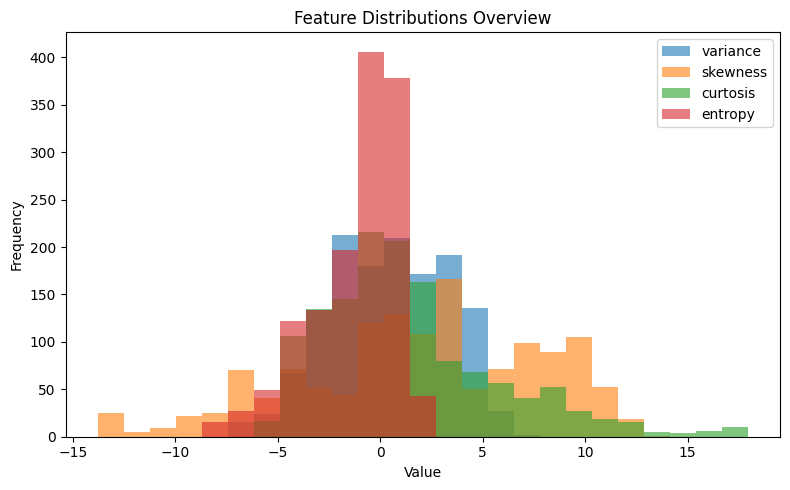

In [ ]:
plt.figure(figsize=(8, 5))
raw[FEATURES].plot(kind='hist', bins=25, alpha=0.6, subplots=False, legend=True, ax=plt.gca())
plt.title("Feature Distributions Overview")
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig("1_feature_distributions.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

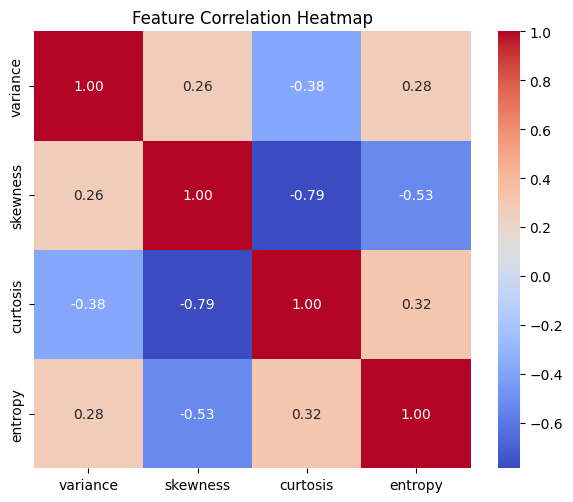

In [ ]:
plt.figure(figsize=(6, 5))
sns.heatmap(raw[FEATURES].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()

plt.savefig("2_correlation_heatmap.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(7, 5))
for cls, sub in raw.groupby('label'):
    plt.scatter(sub['variance'], sub['skewness'], s=15, alpha=0.6,
                color=palette[cls], label=f"Class {cls} ({'Forged' if cls==1 else 'Authentic'})")

plt.xlabel("Variance")
plt.ylabel("Skewness")
plt.title("Variance vs Skewness Class Distribution")
plt.legend()
plt.tight_layout()

plt.savefig("3_variance_vs_skewness_scatter.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

NameError: name 'palette' is not defined

<Figure size 700x500 with 0 Axes>

In [ ]:
plt.figure(figsize=(8, 5))
melted = raw.melt(id_vars='label', value_vars=FEATURES)
sns.boxplot(data=melted, x='variable', y='value', hue='label', palette=palette)
plt.title("Feature Spread and Outlier Analysis by Class")
plt.xlabel("Features")
plt.ylabel("Value Range")
plt.legend(title="Label")
plt.tight_layout()

plt.savefig("4_feature_boxplots.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Preprocessing
X = raw[FEATURES].to_numpy()
y = raw['label'].to_numpy()

mu, sigma = X.mean(axis=0), X.std(axis=0)
X_std = (X - mu) / sigma

X_train, X_test, y_train, y_test = train_test_split(
    X_std, y, test_size=0.2, random_state=7, stratify=y
)
print(f"Train: {X_train.shape[0]} | Test: {X_test.shape[0]}")

In [ ]:
# Perceptron
class BinaryPerceptron:
    def __init__(self, lr=0.01, max_epochs=60, seed=7):
        self.lr = lr
        self.max_epochs = max_epochs
        self.rng = np.random.RandomState(seed)
        self.w = None
        self.b = None
        self.log = []

    @staticmethod
    def _step(z):
        return np.where(z >= 0, 1, 0)

    def fit(self, X, y, verbose=True):
        n_features = X.shape[1]
        self.w = self.rng.normal(0, 0.01, n_features)
        self.b = 0.0
        n = len(X)

        for epoch in range(1, self.max_epochs + 1):
            order = self.rng.permutation(n)
            errors = 0
            for i in order:
                xi, yi = X[i], y[i]
                pred = self._step(np.dot(xi, self.w) + self.b)
                delta = self.lr * (yi - pred)
                if delta != 0:
                    self.w += delta * xi
                    self.b += delta
                    errors += 1

            self.log.append({'epoch': epoch, 'errors': errors,
                              'weights': self.w.copy(), 'bias': self.b})

            if verbose and (epoch == 1 or epoch % 10 == 0 or errors == 0):
                print(f"epoch {epoch:2d} | errors {errors:3d} | bias {self.b:+.4f} | w {np.round(self.w,3)}")

            if errors == 0:
                print(f"Converged at epoch {epoch}.")
                break
        return self

    def predict(self, X):
        return self._step(np.dot(X, self.w) + self.b)

model = BinaryPerceptron(lr=0.01, max_epochs=60).fit(X_train, y_train)
history = pd.DataFrame(model.log)
history.head()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['epoch'], history['errors'], color='#e76f51', marker='o', ms=3)
plt.title("Training Errors vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Misclassified Samples")
plt.tight_layout()

plt.savefig("7_training_errors_vs_epoch.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
W = np.vstack(history['weights'])
for j, feat in enumerate(FEATURES):
    plt.plot(history['epoch'], W[:, j], label=feat)

plt.title("Weight Evolution Analysis")
plt.xlabel("Epoch")
plt.ylabel("Weight Value")
plt.legend(fontsize=8, title="Features")
plt.tight_layout()

plt.savefig("8_weight_evolution.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
plt.figure(figsize=(6, 4))
plt.plot(history['epoch'], history['bias'], color='#264653')
plt.title("Bias Evolution Analysis")
plt.xlabel("Epoch")
plt.ylabel("Bias Value")
plt.tight_layout()

plt.savefig("9_bias_evolution.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Evaluation
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred, target_names=['Authentic (0)', 'Forged (1)']))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Authentic', 'Forged'], yticklabels=['Authentic', 'Forged'])
plt.xlabel("Predicted"); plt.ylabel("Actual"); plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# learning rate comparison
rates = [0.001, 0.01, 0.1]
plt.figure(figsize=(7, 4))

for lr in rates:
    m = BinaryPerceptron(lr=lr, max_epochs=60).fit(X_train, y_train, verbose=False)
    errs = pd.DataFrame(m.log)['errors']
    plt.plot(range(1, len(errs)+1), errs, label=f"lr={lr}")

plt.title("Convergence Behaviour Across Learning Rates")
plt.xlabel("Epoch")
plt.ylabel("Errors")
plt.legend()
plt.tight_layout()

plt.savefig("10_learning_rate_comparison.eps", format='eps', dpi=200, bbox_inches='tight')

plt.show()

In [ ]:
from sklearn.metrics.pairwise import paired_cosine_distances

#  DECISION BOUNDARY PLOT
two_feat = ['variance', 'skewness']
Xv = raw[two_feat].to_numpy()
Xv = (Xv - Xv.mean(0)) / Xv.std(0)

y_target = raw['label'].to_numpy() if 'label' in raw.columns else raw['class'].to_numpy()

Xv_tr, Xv_te, yv_tr, yv_te = train_test_split(Xv, y_target, test_size=0.2, random_state=7, stratify=y_target)

# Fit scratch model on 2 features
m2 = BinaryPerceptron(lr=0.01, max_epochs=60).fit(Xv_tr, yv_tr, verbose=False)

x_min, x_max = Xv[:,0].min()-1, Xv[:,0].max()+1
y_min, y_max = Xv[:,1].min()-1, Xv[:,1].max()+1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid_pred = m2.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(6, 5))

plt.pcolormesh(xx, yy, grid_pred, cmap='Pastel1', shading='auto')

# Plot test points
for cls, sub in zip([0, 1], [Xv_te[yv_te==0], Xv_te[yv_te==1]]):
    plt.scatter(sub[:,0], sub[:,1], s=15, label=f"Class {cls}")

plt.xlim(x_min, x_max)
plt.ylim(y_min, y_max)
plt.xlabel("Variance (std)")
plt.ylabel("Skewness (std)")
plt.title("Decision Boundary (Variance vs Skewness)")
plt.legend()
plt.tight_layout()

plt.savefig("11_decision_boundary.eps", format='eps', dpi=200, bbox_inches='tight')
plt.show()


# SKLEARN MODEL COMPARISON
sk = SKPerceptron(max_iter=60, eta0=0.01, random_state=7).fit(X_train, y_train)

scratch_acc = (model.predict(X_test) == y_test).mean()
sklearn_acc = sk.score(X_test, y_test)

print("\n")
print("      PERFORMANCE COMPARISON EVAL         ")
print(f"Scratch model accuracy : {scratch_acc:.4f}")
print(f"Sklearn Perceptron acc : {sklearn_acc:.4f}")